In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Use the original DataFrame for this check (dataset was overwritten in cell 2)
train_df = pd.read_csv('trainNew.csv')
train_df['Sex'].isnull().sum()

np.int64(0)

In [3]:
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df['Embarked'] = train_df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

In [4]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
train_df['Age'] = imputer.fit_transform(train_df[['Age']])


In [5]:
print(train_df[['Sex', 'Embarked', 'Age']].head(10))

   Sex  Embarked        Age
0    0       2.0  22.000000
1    1       0.0  38.000000
2    1       2.0  26.000000
3    1       2.0  35.000000
4    0       2.0  35.000000
5    0       1.0  29.699118
6    0       2.0  54.000000
7    0       2.0   2.000000
8    1       2.0  27.000000
9    1       0.0  14.000000


In [6]:
col_todrop = ['Name', 'Ticket', 'Cabin', 'Embarked']
train_df = train_df.drop(col_todrop, axis=1)
print(train_df.head(10))

   PassengerId  Survived  Pclass  Sex        Age  SibSp  Parch     Fare
0            1         0       3    0  22.000000      1      0   7.2500
1            2         1       1    1  38.000000      1      0  71.2833
2            3         1       3    1  26.000000      0      0   7.9250
3            4         1       1    1  35.000000      1      0  53.1000
4            5         0       3    0  35.000000      0      0   8.0500
5            6         0       3    0  29.699118      0      0   8.4583
6            7         0       1    0  54.000000      0      0  51.8625
7            8         0       3    0   2.000000      3      1  21.0750
8            9         1       3    1  27.000000      0      2  11.1333
9           10         1       2    1  14.000000      1      0  30.0708


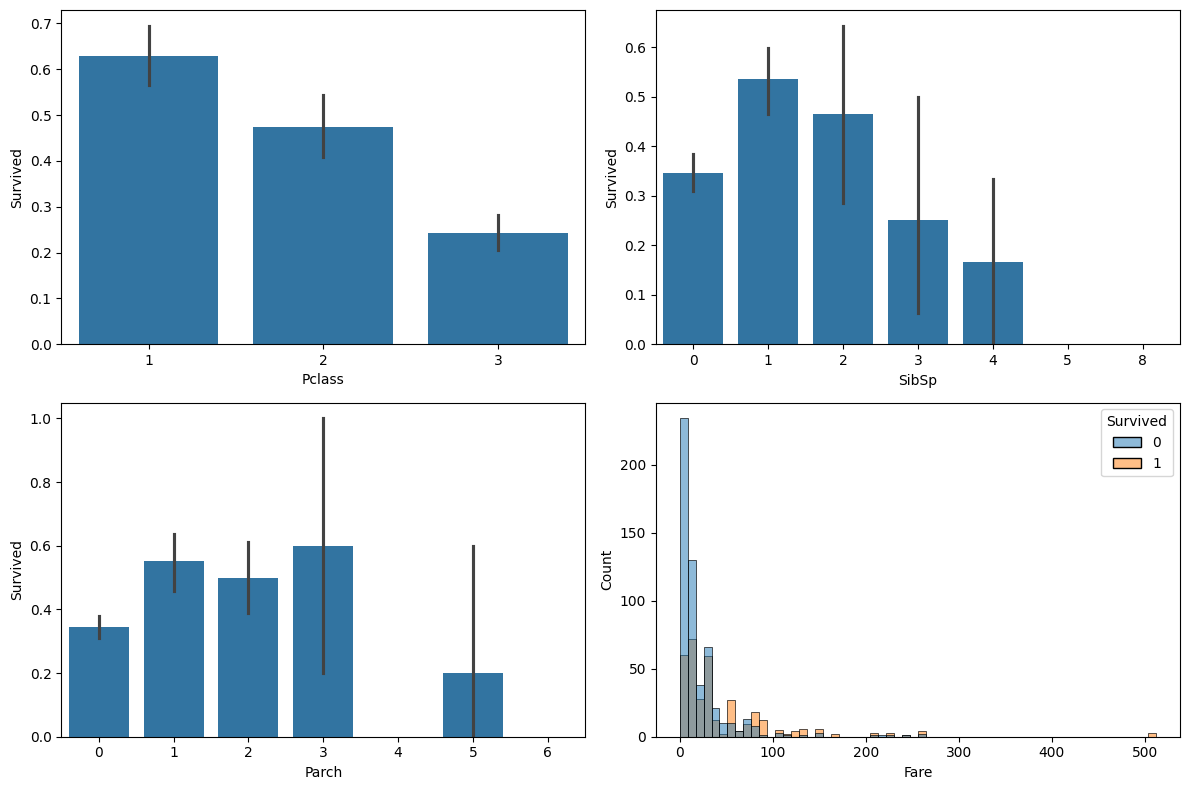

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(x='Pclass', y='Survived', data=train_df, ax=axes[0,0])
sns.barplot(x='SibSp', y='Survived', data=train_df, ax=axes[0,1])
sns.barplot(x='Parch', y='Survived', data=train_df, ax=axes[1,0])
sns.histplot(data=train_df, x='Fare', hue='Survived', ax=axes[1,1])

plt.tight_layout()
plt.show()

In [8]:
print(train_df.to_csv('trainPre.csv', index=False))

None


In [9]:
train_df = train_df.drop('PassengerId', axis=1)

In [10]:
print(train_df.to_csv('trainPre.csv', index=False))

None


In [11]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
train_df[['Age', 'Fare']] = scaler.fit_transform(train_df[['Age', 'Fare']])

In [12]:
print(train_df.to_csv('trainPre.csv', index=False))

None


In [13]:
X = train_df.iloc[:, 1:].values
y = train_df.iloc[:, 0].values
print(X)
print(y)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


[[ 3.          0.         -0.5924806   1.          0.         -0.50244517]
 [ 1.          1.          0.63878901  1.          0.          0.78684529]
 [ 3.          1.         -0.2846632   0.          0.         -0.48885426]
 ...
 [ 3.          1.          0.          1.          2.         -0.17626324]
 [ 1.          0.         -0.2846632   0.          0.         -0.04438104]
 [ 3.          0.          0.17706291  0.          0.         -0.49237783]]
[0 1 1 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 0 1
 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0
 1 0 0 0 1 1 0 1 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1 0
 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1
 0 1 1 0 0 1 0 1 1 1 1 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 1 0
 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 1
 1 0 1 0 0 0 0 0 1 

In [14]:
from sklearn.linear_model import LogisticRegression
classifierL = LogisticRegression(random_state=0)
classifierL.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
y_pred = classifierL.predict(X_test)

In [16]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


[[92 13]
 [21 53]]
0.8100558659217877


In [17]:
from sklearn.ensemble import RandomForestClassifier
classifierR = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
classifierR.fit(X_train, y_train)
y_pred = classifierR.predict(X_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[91 14]
 [20 54]]


In [18]:
from sklearn.model_selection import cross_val_score

# Replace 'model' with YOUR variable name 'classifier'
scores = cross_val_score(classifierR, X, y, cv=5)
print(f"Average Accuracy: {scores.mean():.4f}")

Average Accuracy: 0.8205


In [19]:
# Load test data
test_df = pd.read_csv('test.csv')

# Apply SAME steps as training - but transform only, don't fit again
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
test_df['Embarked'] = test_df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# Handle missing values (Age and Fare - test has 1 missing Fare)
test_df['Age'] = imputer.transform(test_df[['Age']])
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

# Drop same columns
test_df = test_df.drop(['Name', 'Ticket', 'Cabin', 'Embarked'], axis=1)

# Scale using the SAME scaler - transform only!
test_df[['Age', 'Fare']] = scaler.transform(test_df[['Age', 'Fare']])

# Make predictions
test_predictions = classifierR.predict(test_df.drop('PassengerId', axis=1))

# Create submission file
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_predictions
})
submission.to_csv('submission.csv', index=False)

c:\Users\PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [20]:
print(test_df.shape)

(418, 7)
